## Assignment 2: Time Series Forecasting

### your name, your id, Version NN

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

### 1. Paper evaluation

(Candanedo, LM, Feldheim, V & Deramaix, D 2017, 'Data driven prediction models of energy use of appliances in a low-energy house', Energy and buildings, vol. 140, pp. 81-97.)
https://myuni.adelaide.edu.au/courses/105130/files/16388685?wrap=1

In [1]:

import pandas as pd 
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

import warnings
warnings.filterwarnings("ignore")

### 2. Analyse and visualise the Time Series

In [2]:
data = pd.read_csv('energydata_complete.csv')
df = data.copy()
df = df[['Appliances', 'date']]
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df.head()

,Appliances
date,
2016-02-14 00:00:00,50
2016-02-14 00:10:00,50
2016-02-14 00:20:00,60
2016-02-14 00:30:00,40
2016-02-14 00:40:00,60


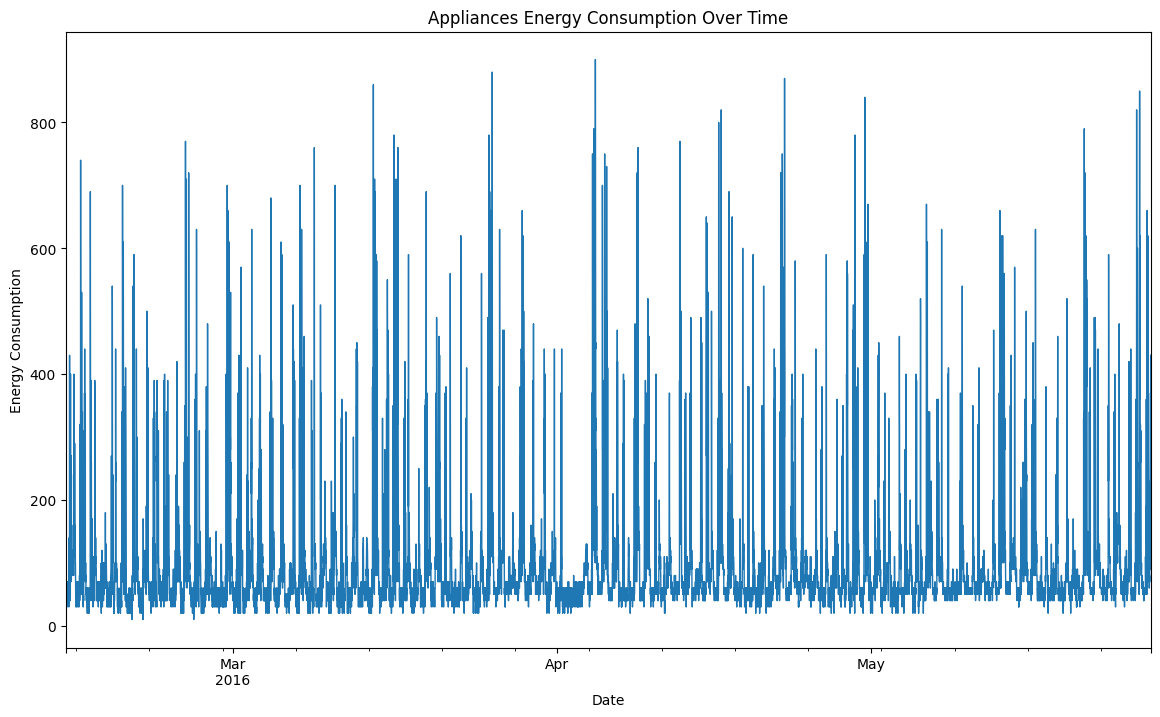

In [3]:
df['Appliances'].plot(figsize=(14, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.show()

As can be seen above, the time series does not yield any obvious trend on energy usage (Appliances) overtime. However, the absence of pattern does not necessarily imply that the data is stable. For further stationary checking, let's plot the simple moving average

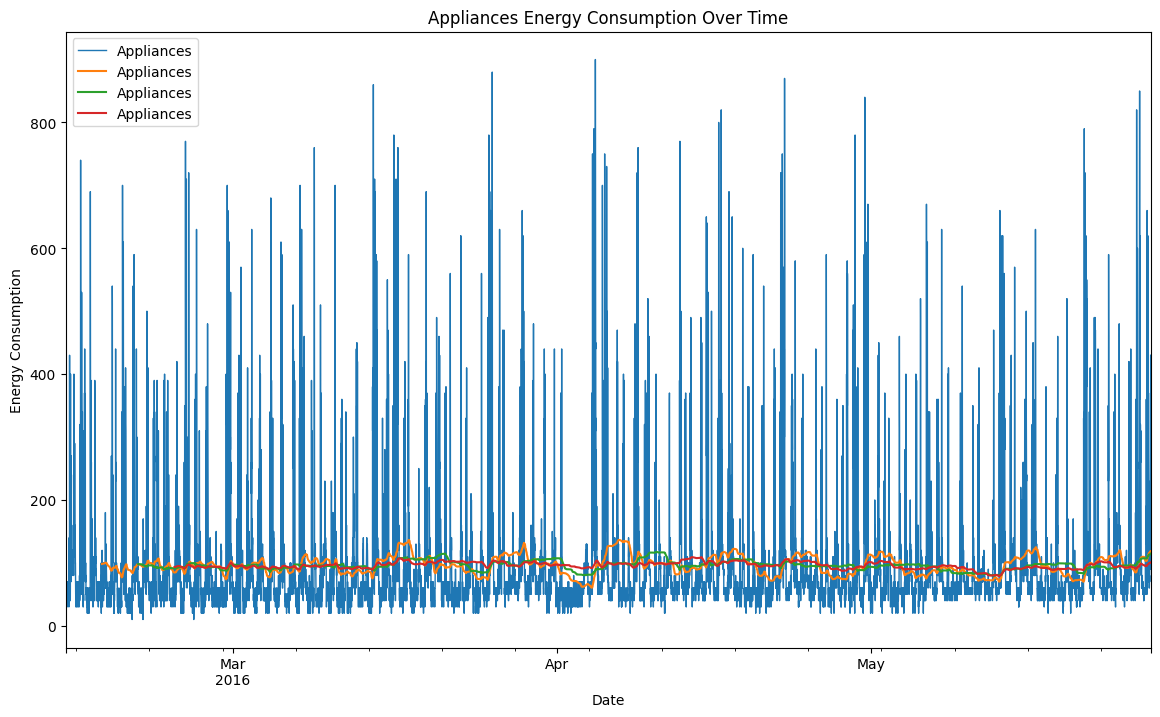

In [4]:
df_sma_500 = df['Appliances'].rolling(window=500).mean()
df_sma_1000 = df['Appliances'].rolling(window=1000).mean()
df_sma_1500 = df['Appliances'].rolling(window=1500).mean()

df['Appliances'].plot(figsize=(14, 8), title='Appliances Energy Consumption Over Time', linewidth=1)
df_sma_500.plot()
df_sma_1000.plot()
df_sma_1500.plot()
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.legend()
plt.show()

Even with averaging, the series is still stable, suggesting the series may already be stationary

### 3. Pre-process the data

In [5]:
#Spliting
train_dev_size = int(len(df) * 0.75)

df_train_dev = df.iloc[:train_dev_size] 
df_test = df.iloc[train_dev_size:]

print(f"df_train_dev shape: {df_train_dev.shape}")
print(f"df_test shape: {df_test.shape}")

df_train_dev shape: (11205, 1)
df_test shape: (3736, 1)


### 4. Model training and selection

In [6]:
# Time series techniques (cite Module 5 Online learning/chapter 12)
# 1. Decomposition
# 2. Smoothing based techniques
# 3. Regression based techniques
# 4. machine learning-based techniques

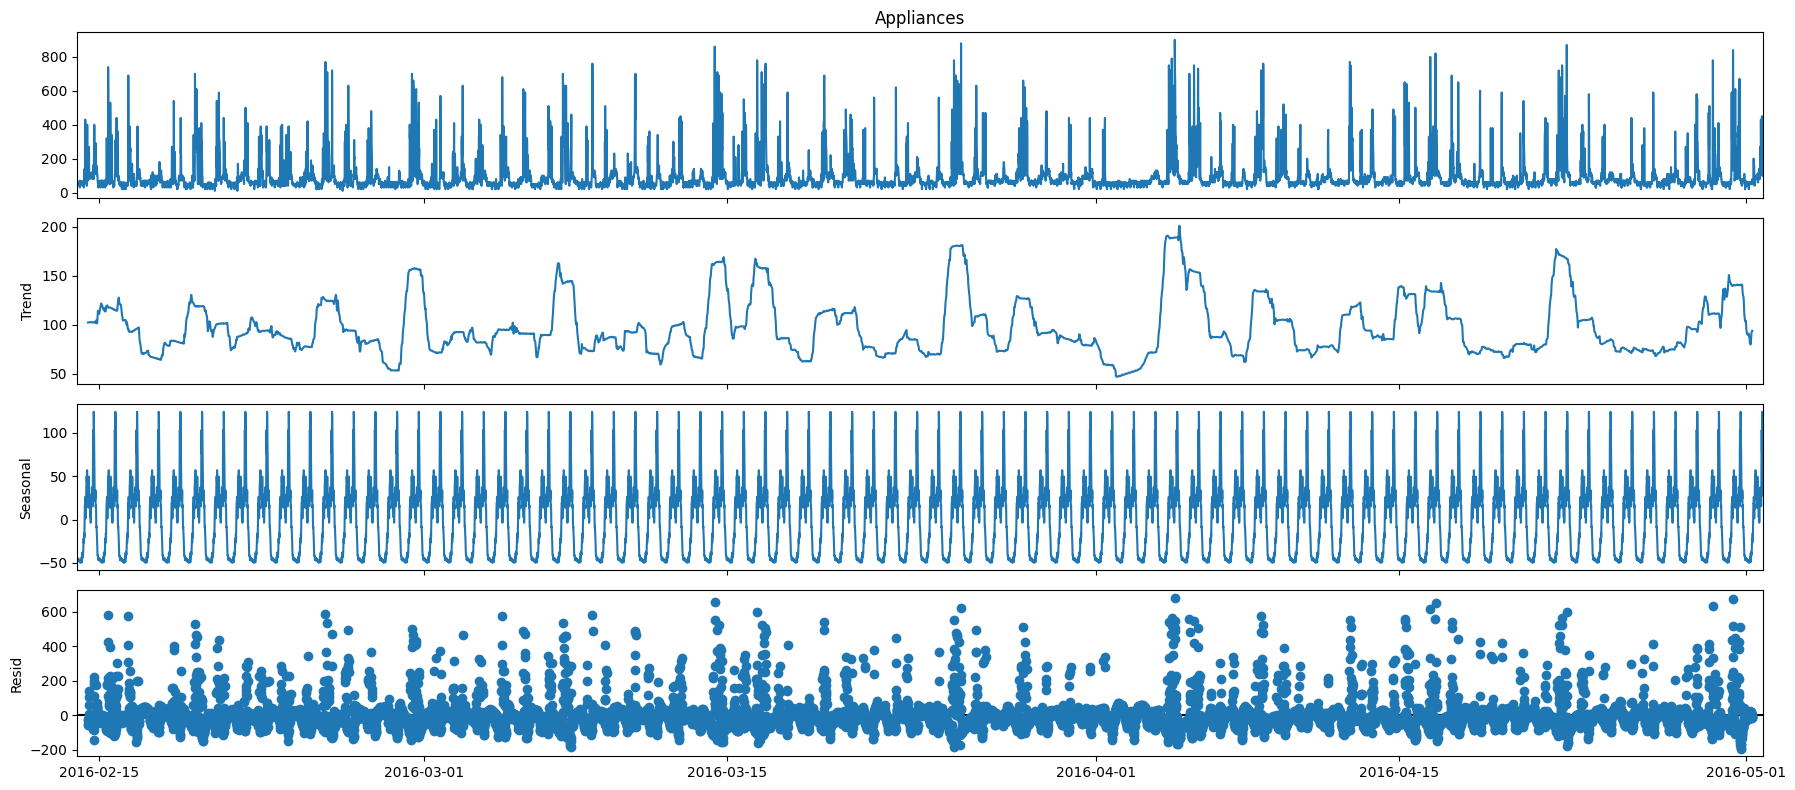

In [ ]:
# Decomposition

rcParams['figure.figsize'] = 18, 8

decomposition = seasonal_decompose(df_train_dev['Appliances'], model='additive', period=144) #24*60/10=144 Daily data
decomposition.plot()
plt.show()



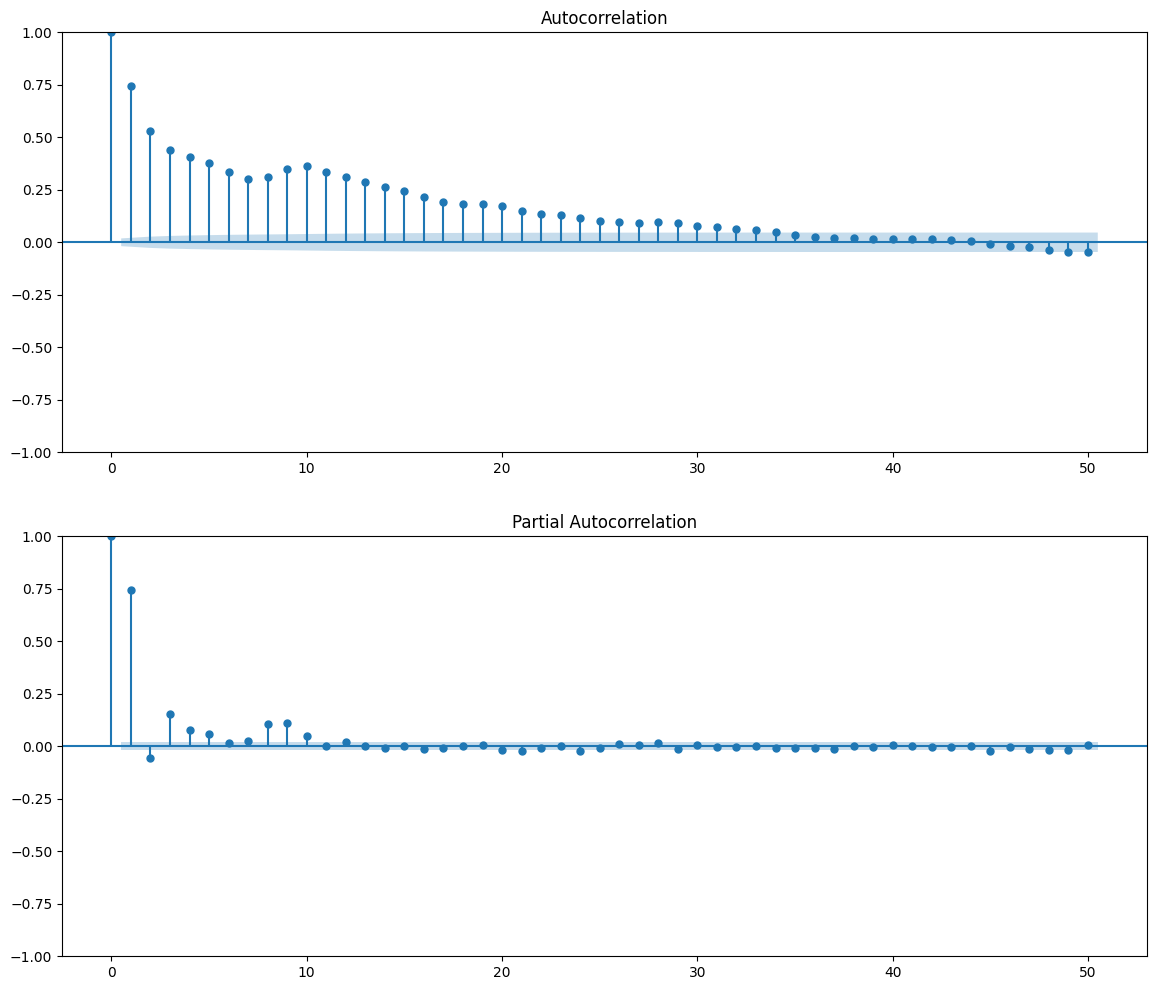

In [7]:
# As dicussed before, the time series is stationary, so we will choose d = 0 for the ARIMA model
# We will use the ACF and PACF plots to determine the values of p and q

# Finding p and q 

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 12))

plot_acf(df_train_dev['Appliances'], lags=50, ax=ax[0])
plot_pacf(df_train_dev['Appliances'], lags=50, ax=ax[1])
plt.show()


p = q = 3

In [8]:
df_train_dev

,Appliances
date,
2016-02-14 00:00:00,50
2016-02-14 00:10:00,50
2016-02-14 00:20:00,60
2016-02-14 00:30:00,40
2016-02-14 00:40:00,60
...,...
2016-05-01 18:40:00,120
2016-05-01 18:50:00,110
2016-05-01 19:00:00,120


                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                11205
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -62864.498
Date:                Tue, 11 Mar 2025   AIC                         125742.996
Time:                        20:34:17   BIC                         125794.264
Sample:                    02-14-2016   HQIC                        125760.252
                         - 05-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1416      0.541     -0.262      0.793      -1.202       0.918
ar.L2          0.1658      0.215      0.770      0.441      -0.256       0.588
ar.L3          0.0378      0.027      1.398      0.1

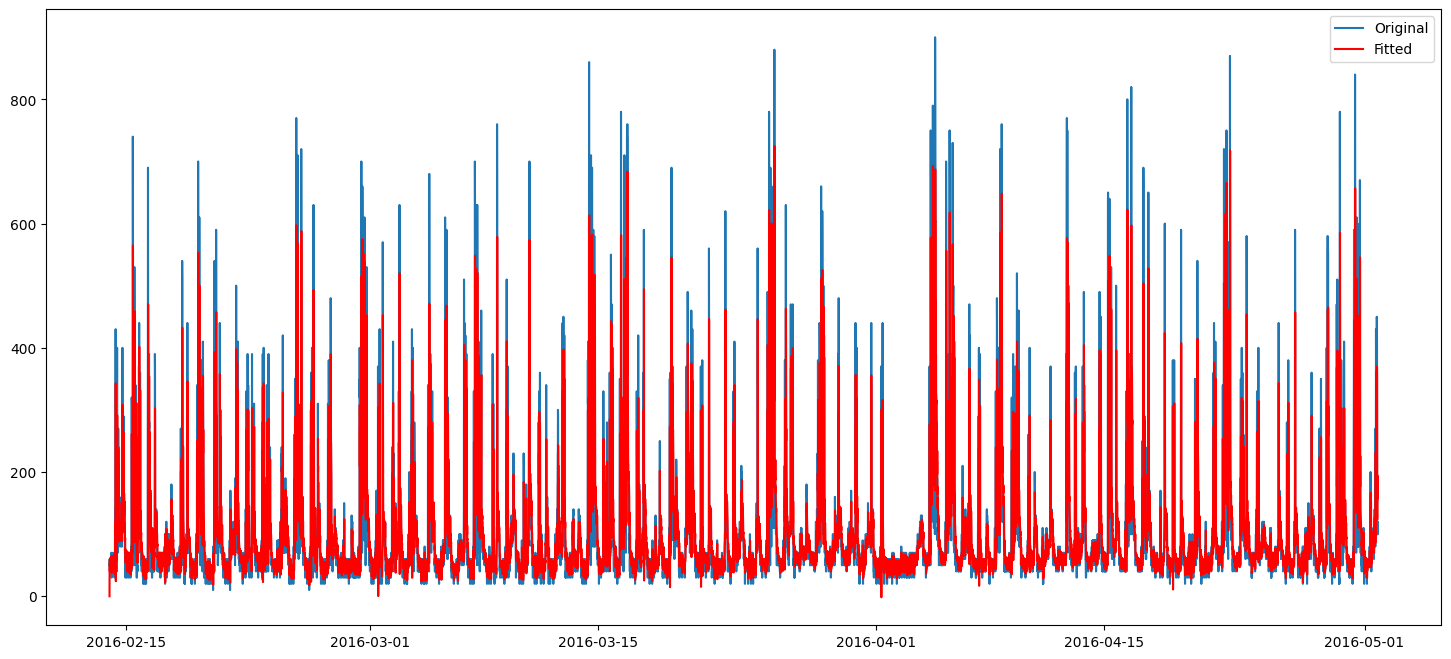

In [ ]:
import statsmodels.api as sm

model_arima = sm.tsa.arima.ARIMA(df_train_dev['Appliances'], order=(3,1,3)) #p=3, d=1(because it is stationary), q=3
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())
plt.plot(df_train_dev['Appliances'], label='Original')
plt.plot(model_arima_fit.fittedvalues, color='red', label='Fitted')
plt.legend()
plt.show()

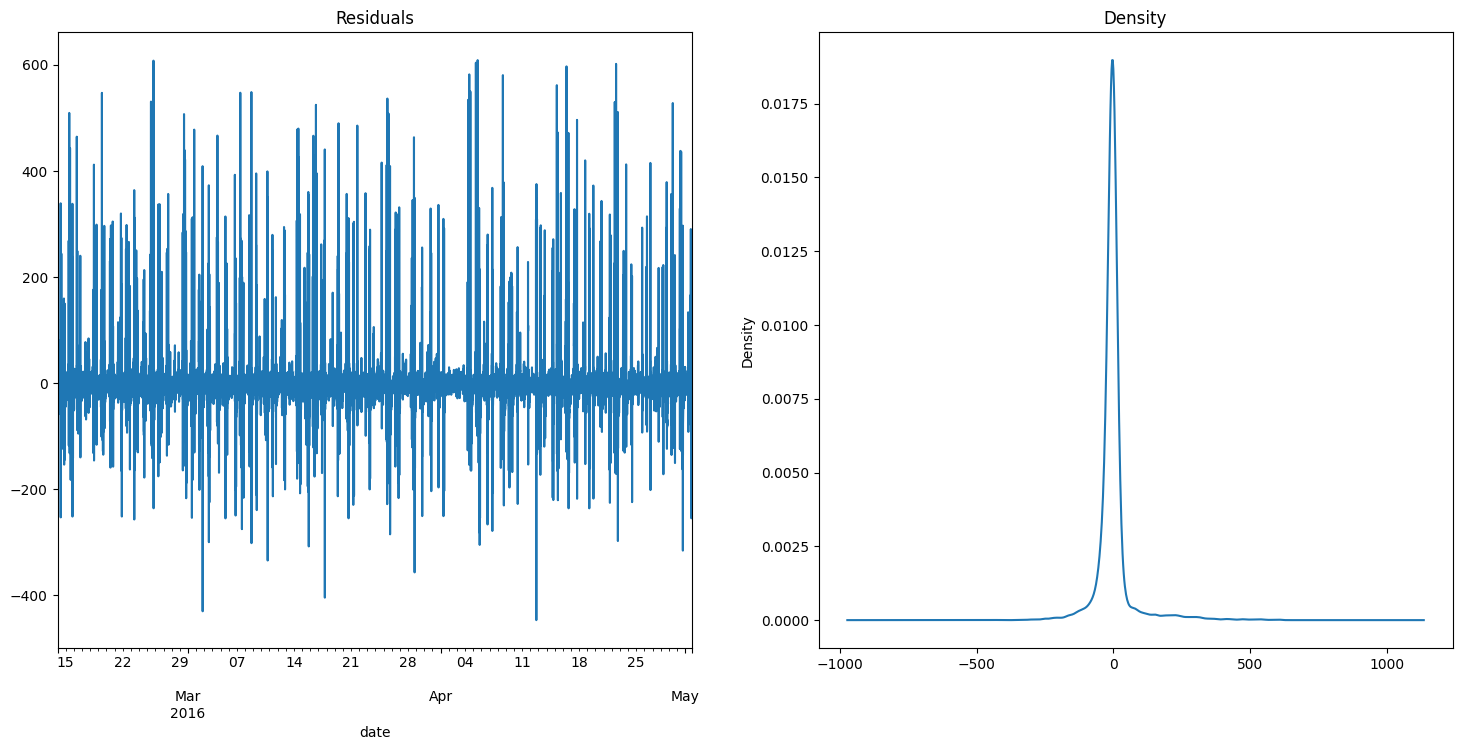

In [14]:
residuals = model_arima_fit.resid
fig, ax = plt.subplots(1,2)
residuals.plot(title='Residuals', ax=ax[0])
residuals.plot(title='Density', kind='kde', ax=ax[1])
plt.show()

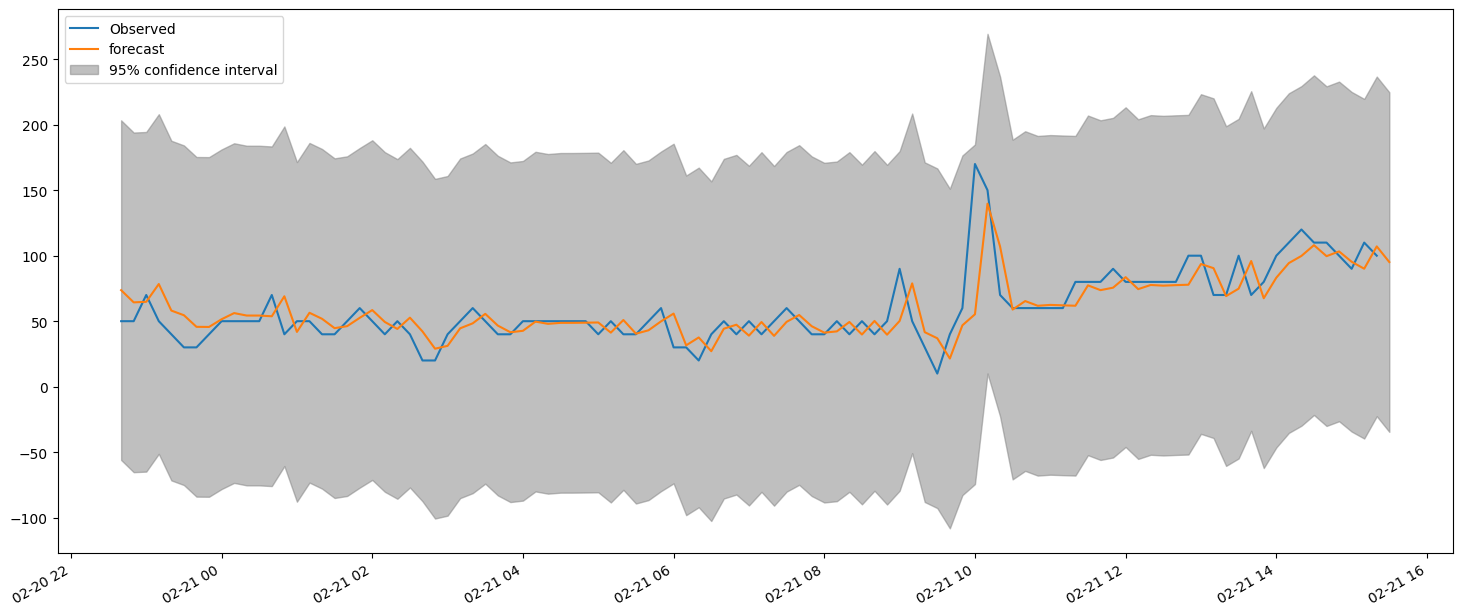

In [11]:
from statsmodels.graphics.tsaplots import plot_predict

fig, ax = plt.subplots()

# Plot the ground truth
ax.plot(df_train_dev['Appliances'].iloc[1000:1101], label='Observed')

# Plot the predicted values

plot_predict(model_arima_fit, start=1000, end=1101, ax=ax)

plt.legend()
plt.show()

In [15]:
#Auto ARIMA

from pmdarima import auto_arima

auto_arima = auto_arima(df_train_dev, stepwise=False, seasonal=False)
auto_arima

ARIMA(order=(4, 0, 1), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                11205
Model:                 ARIMA(4, 0, 1)   Log Likelihood              -62776.565
Date:                Tue, 11 Mar 2025   AIC                         125567.129
Time:                        20:56:47   BIC                         125618.398
Sample:                    02-14-2016   HQIC                        125584.386
                         - 05-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.6724      8.649     11.292      0.000      80.720     114.625
ar.L1          1.6023      0.016     99.286      0.000       1.571       1.634
ar.L2         -0.8149      0.015    -55.172      0.0

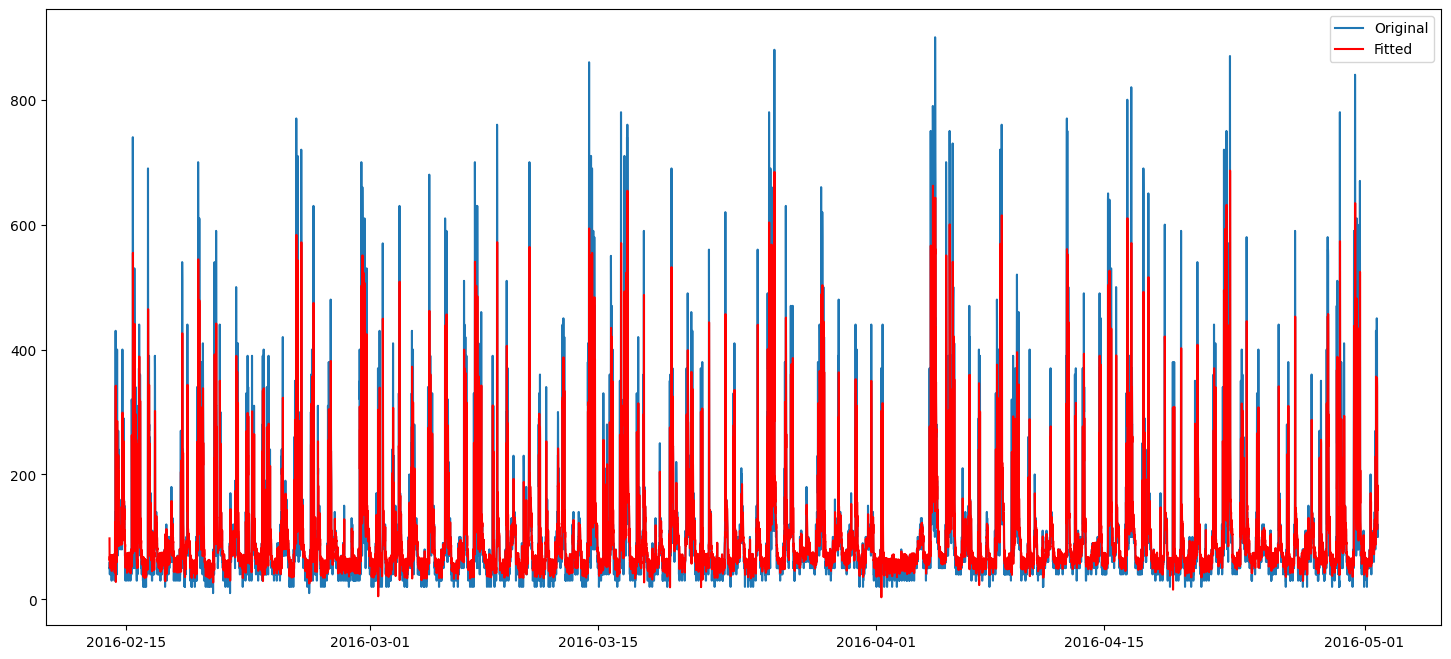

In [23]:
model_auto_arima = sm.tsa.arima.ARIMA(df_train_dev['Appliances'], order=(4, 0, 1))
model_auto_arima_fit = model_auto_arima.fit()
print(model_auto_arima_fit.summary())
plt.plot(df_train_dev['Appliances'], label='Original')
plt.plot(model_auto_arima_fit.fittedvalues, color='red', label='Fitted')
plt.legend()
plt.show()

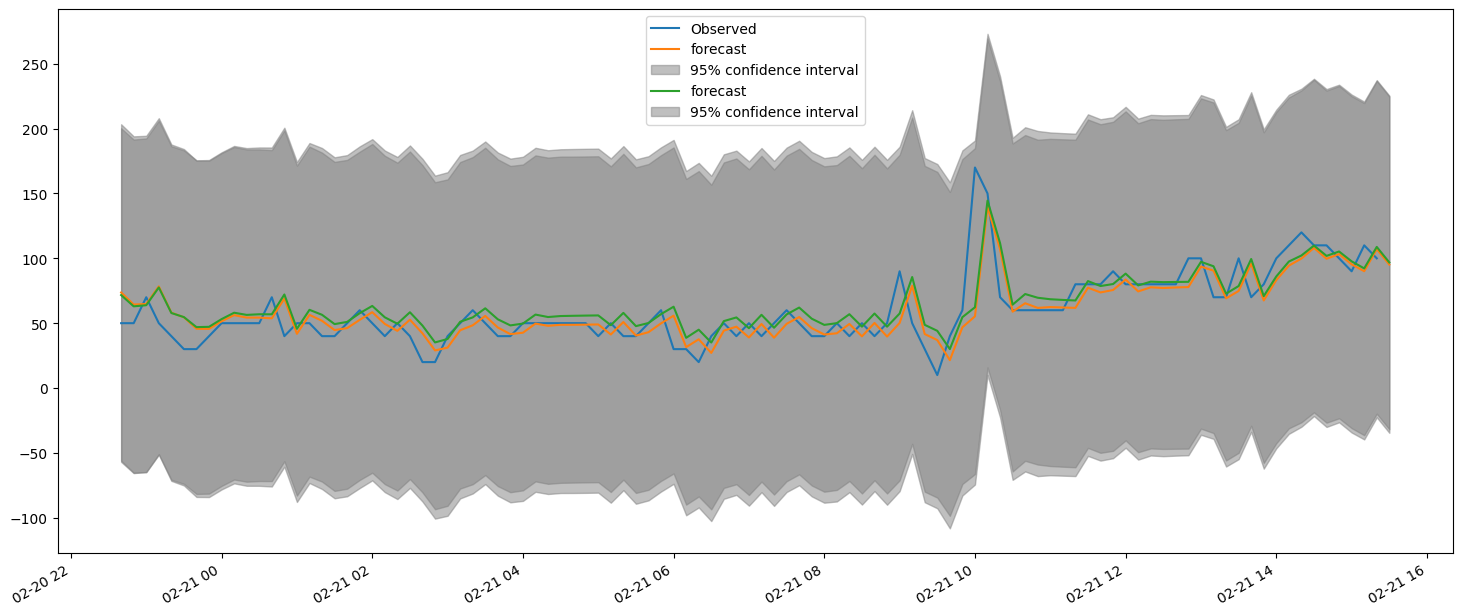

In [ ]:
fig, ax = plt.subplots()

# Plot the ground truth
ax.plot(df_train_dev['Appliances'].iloc[1000:1101], label='Observed')

# Plot the predicted values

plot_predict(model_arima_fit, start=1000, end=1101, ax=ax, label='ARIMA')
plot_predict(model_auto_arima_fit, start=1000, end=1101, ax=ax, label='Auto ARIMA')

# ORANGE = Manual ARIMA
# GREEN = Auto ARIMA

plt.legend()
plt.show()

### LTSM

In [42]:
# build LSTM Model for time series forecasting using Pytorch

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils

def create_dataset(dataset, look_back=1):
    """
    this function creates a dataset for the LSTM model
    :param dataset: the dataset
    :param look_back: the number of previous time steps to use as input variables to predict the next time period
    :return: the input and output dataset in the form of torch tensors
    """
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        feature = dataset[i:(i+look_back)]
        dataX.append(feature)
        target = dataset[i+1: i+look_back+1]
        dataY.append(target)
    return torch.Tensor(dataX), torch.Tensor(dataY)

# further split df_train_dev into train and dev sets
train_size = int(len(df_train_dev) * 0.8)
df_train = df_train_dev.iloc[:train_size]
df_dev = df_train_dev.iloc[train_size:]

lookback = 1
X_train, y_train = create_dataset(df_train['Appliances'].values, lookback)
X_dev, y_dev = create_dataset(df_dev['Appliances'].values, lookback)

X_train = X_train.unsqueeze(-1)  # Add last dimension to match (batch_size, seq_length, input_size)
X_dev = X_dev.unsqueeze(-1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_dev shape: {X_dev.shape}")
print(f"y_dev shape: {y_dev.shape}")


X_train shape: torch.Size([8962, 1, 1])
y_train shape: torch.Size([8962, 1])
X_dev shape: torch.Size([2239, 1, 1])
y_dev shape: torch.Size([2239, 1])


Epoch: 0, Loss: 56743.8203125
Epoch: 0, Train Loss: 15178.69921875, Dev Loss: 15579.162109375
Epoch: 1, Train Loss: 12757.9287109375, Dev Loss: 13096.21484375
Epoch: 2, Train Loss: 11371.4912109375, Dev Loss: 11671.021484375
Epoch: 3, Train Loss: 10370.2744140625, Dev Loss: 10652.580078125
Epoch: 4, Train Loss: 9613.9033203125, Dev Loss: 9888.751953125
Epoch: 5, Train Loss: 8951.1845703125, Dev Loss: 9218.4296875
Epoch: 6, Train Loss: 8450.330078125, Dev Loss: 8684.2880859375
Epoch: 7, Train Loss: 7949.85498046875, Dev Loss: 8202.595703125
Epoch: 8, Train Loss: 7495.2939453125, Dev Loss: 7714.55224609375
Epoch: 9, Train Loss: 7145.8427734375, Dev Loss: 7339.60986328125
Epoch: 10, Train Loss: 6806.314453125, Dev Loss: 6989.08349609375
Epoch: 11, Train Loss: 6517.38916015625, Dev Loss: 6683.78466796875
Epoch: 12, Train Loss: 6279.14599609375, Dev Loss: 6415.353515625
Epoch: 13, Train Loss: 6115.6044921875, Dev Loss: 6256.97314453125
Epoch: 14, Train Loss: 6014.650390625, Dev Loss: 6151.5

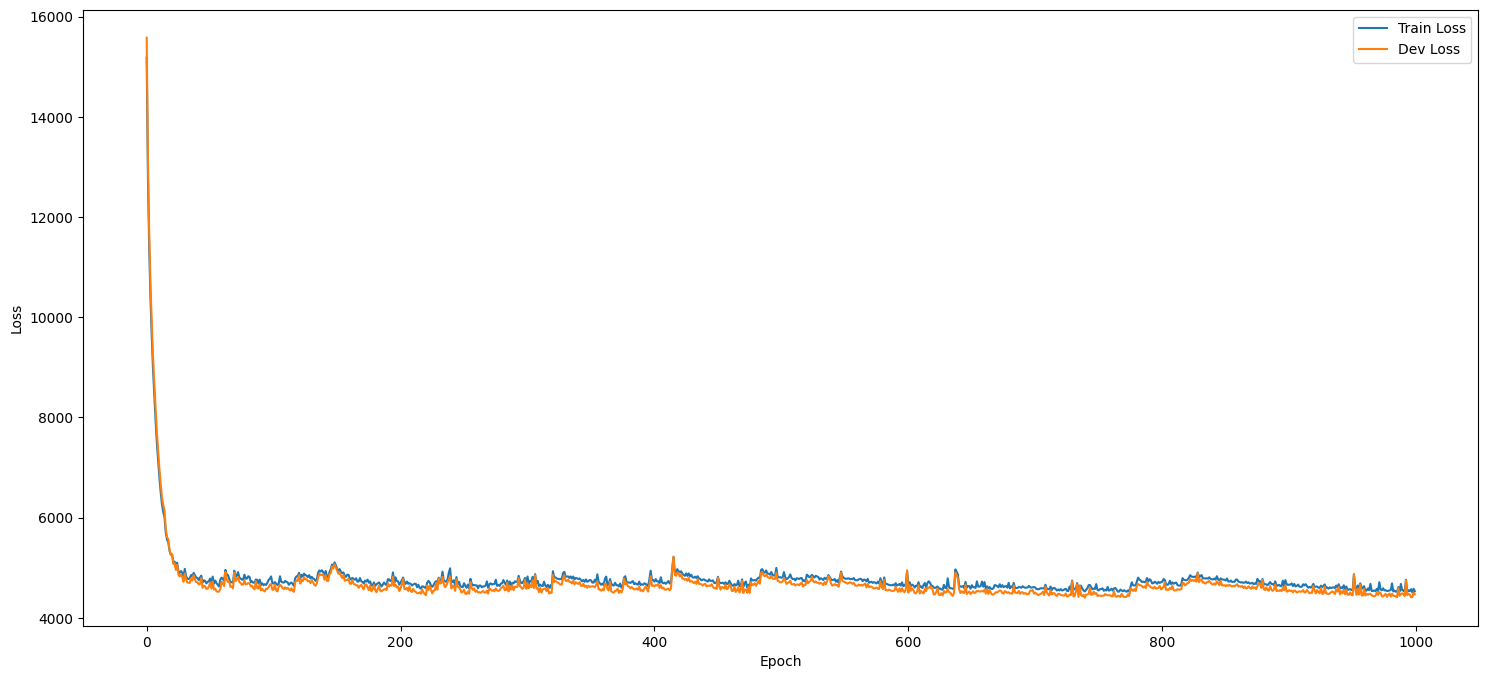

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils

class MyLSTM(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super(MyLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, X):
        batch_size = X.shape[0]  # Get batch size dynamically

        # Initialize hidden and cell states correctly
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_layer_size).to(X.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_layer_size).to(X.device)

        # Forward pass through LSTM
        lstm_out, _ = self.lstm(X, (h0, c0))
        
        # Apply the linear layer to the last time step's output
        predictions = self.linear(lstm_out[:, -1, :])  # Taking only the last timestep output

        return predictions  # Return predictions

    
model = MyLSTM(input_size=1, hidden_layer_size=100, output_size=1, num_layers=1)
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()

loader = data_utils.DataLoader(data_utils.TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

training_history = []

n_epochs = 1000
for epoch in range(n_epochs):
    model.train()
    for i, (X_batch, y_batch) in enumerate(loader):
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')
        
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        y_pred_dev = model(X_dev)
        loss_train = loss_fn(y_pred_train, y_train)
        loss_dev = loss_fn(y_pred_dev, y_dev)
        
        training_history.append((loss_train, loss_dev))
        print(f'Epoch: {epoch}, Train Loss: {loss_train.item()}, Dev Loss: {loss_dev.item()}')
            
# save to json 

import json

training_history_dict = {
    'train': [loss_train.item() for loss_train, _ in training_history],
    'dev': [loss_dev.item() for _, loss_dev in training_history]
}

with open('training_history.json', 'w') as f:
    json.dump(training_history_dict, f)

# Plot the training history

plt.plot(training_history_dict['train'], label='Train Loss')
plt.plot(training_history_dict['dev'], label='Dev Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
    

### 5. Testing and analysis of the final model


### 6. Reflection

### 7. References

### 8. Appendix